## Generate Synthetic Stock Trade Data

In [ ]:
# Install Faker if not already installed
%pip install Faker

import pandas as pd
import numpy as np
from faker import Faker
import random
from datetime import datetime, timedelta

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 22.9 MB/s eta 0:00:00


### Dataset Parameters

In [ ]:
fake = Faker()

NUM_TRADES = 50000

tickers = ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'TSLA', 'NVDA', 'BRK.A', 'JPM', 'V', 'PG', 'KO', 'PEP', 'DIS', 'NFLX', 'SBUX', 'ADBE', 'CRM', 'INTC', 'CSCO', 'XOM', 'CVX', 'WMT', 'HD', 'BAC', 'GS', 'GE']
brokerages = ['Charles Schwab', 'Interactive Brokers']

start_date = datetime(2020, 1, 1)
end_date = datetime(2023, 12, 31)

### Generate Data with Inconsistencies and Nulls

In [ ]:
data = []
for _ in range(NUM_TRADES):
    trade_date = start_date + timedelta(days=random.randint(0, (end_date - start_date).days))
    ticker = random.choice(tickers)
    trade_type = random.choice(['Buy', 'Sell'])
    quantity = random.randint(1, 1000)
    price = round(random.uniform(10.0, 2000.0), 2)
    brokerage = random.choice(brokerages)

    # Introduce random null values
    if random.random() < 0.02: # 2% nulls for Date
        trade_date = None
    if random.random() < 0.03: # 3% nulls for Ticker
        ticker = None
    if random.random() < 0.01: # 1% nulls for Trade Type
        trade_type = None
    if random.random() < 0.02: # 2% nulls for Quantity
        quantity = None
    if random.random() < 0.02: # 2% nulls for Price
        price = None
    if random.random() < 0.01: # 1% nulls for Brokerage
        brokerage = None

    # Introduce formatting inconsistencies
    if trade_date is not None:
        if random.random() < 0.2: # 20% of dates in 'MM/DD/YYYY' format
            trade_date = trade_date.strftime('%m/%d/%Y')
        else: # 80% in 'YYYY-MM-DD' format
            trade_date = trade_date.strftime('%Y-%m-%d')

    if ticker is not None and random.random() < 0.15: # 15% of tickers lowercase
        ticker = ticker.lower()

    if quantity is not None and random.random() < 0.1: # 10% of quantities as strings
        quantity = str(quantity)

    if price is not None and random.random() < 0.15: # 15% of prices as strings with currency
        price = f'${price}'

    data.append({
        'Date': trade_date,
        'Ticker': ticker,
        'Buy/Sell': trade_type,
        'Quantity': quantity,
        'Price': price,
        'Brokerage': brokerage
    })

df = pd.DataFrame(data)

### Display the generated DataFrame

In [ ]:
print(f"Generated DataFrame with {len(df)} rows and {len(df.columns)} columns.")
display(df.head())

Generated DataFrame with 50000 rows and 6 columns.


,Date,Ticker,Buy/Sell,Quantity,Price,Brokerage
0,2021-01-03,JPM,Sell,357,365.17,Interactive Brokers
1,2023-06-04,TSLA,Buy,490,$1339.89,Interactive Brokers
2,2022-04-16,BRK.A,Sell,783,707.77,Interactive Brokers
3,2020-12-09,CRM,Sell,342,$368.65,Charles Schwab
4,None,nvda,Buy,923,1531.85,Charles Schwab


### Check for null values and data types

This gives an overview of the introduced inconsistencies for data cleaning practice.

In [ ]:
print("\nDataFrame Info:")
df.info()

print("\nNull values count:")
display(df.isnull().sum().to_frame(name='Null Count'))


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Date       49005 non-null  object
 1   Ticker     48471 non-null  object
 2   Buy/Sell   49518 non-null  object
 3   Quantity   49039 non-null  object
 4   Price      48911 non-null  object
 5   Brokerage  49505 non-null  object
dtypes: object(6)
memory usage: 2.3+ MB

Null values count:


,Null Count
Date,995
Ticker,1529
Buy/Sell,482
Quantity,961
Price,1089
Brokerage,495


## Data Cleaning Steps

### Step 1: Convert 'Date' column to datetime objects

We'll use `pd.to_datetime` with `errors='coerce'` to handle different date formats and turn any unparseable dates into `NaT` (Not a Time), which is pandas' representation for missing datetime values.

In [ ]:
initial_rows = len(df)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce', infer_datetime_format=True)
print(f"'Date' column converted to datetime. {df['Date'].isnull().sum()} nulls introduced/retained.")

# Optionally, remove rows where Date conversion failed (became NaT)
df.dropna(subset=['Date'], inplace=True)
print(f"Removed {initial_rows - len(df)} rows with null 'Date' values. Remaining rows: {len(df)}")

display(df.head())
df.info()

'Date' column converted to datetime. 10856 nulls introduced/retained.
Removed 10856 rows with null 'Date' values. Remaining rows: 39144


/tmp/ipykernel_4399/1026797281.py:2: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce', infer_datetime_format=True)


,Date,Ticker,Buy/Sell,Quantity,Price,Brokerage
0,2021-01-03,JPM,Sell,357,365.17,Interactive Brokers
1,2023-06-04,TSLA,Buy,490,$1339.89,Interactive Brokers
2,2022-04-16,BRK.A,Sell,783,707.77,Interactive Brokers
3,2020-12-09,CRM,Sell,342,$368.65,Charles Schwab
5,2023-05-10,SBUX,Buy,512,853.73,Charles Schwab


<class 'pandas.core.frame.DataFrame'>
Index: 39144 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       39144 non-null  datetime64[ns]
 1   Ticker     37968 non-null  object        
 2   Buy/Sell   38769 non-null  object        
 3   Quantity   38397 non-null  object        
 4   Price      38302 non-null  object        
 5   Brokerage  38752 non-null  object        
dtypes: datetime64[ns](1), object(5)
memory usage: 2.1+ MB


### Step 2: Remove rows with null values in the 'Price' column

Before converting 'Price' to numeric, we'll remove any rows where the 'Price' column is null, as requested.

In [ ]:
initial_rows = len(df)
df.dropna(subset=['Price'], inplace=True)
print(f"Removed {initial_rows - len(df)} rows with null 'Price' values. Remaining rows: {len(df)}")

display(df.head())
df.info()

Removed 842 rows with null 'Price' values. Remaining rows: 38302


,Date,Ticker,Buy/Sell,Quantity,Price,Brokerage
0,2021-01-03,JPM,Sell,357,365.17,Interactive Brokers
1,2023-06-04,TSLA,Buy,490,$1339.89,Interactive Brokers
2,2022-04-16,BRK.A,Sell,783,707.77,Interactive Brokers
3,2020-12-09,CRM,Sell,342,$368.65,Charles Schwab
5,2023-05-10,SBUX,Buy,512,853.73,Charles Schwab


<class 'pandas.core.frame.DataFrame'>
Index: 38302 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       38302 non-null  datetime64[ns]
 1   Ticker     37145 non-null  object        
 2   Buy/Sell   37931 non-null  object        
 3   Quantity   37569 non-null  object        
 4   Price      38302 non-null  object        
 5   Brokerage  37919 non-null  object        
dtypes: datetime64[ns](1), object(5)
memory usage: 2.0+ MB


### Step 3: Convert 'Price' column to numeric

First, we'll remove any '$' symbols from the 'Price' column. Then, we'll convert it to a numeric type, again using `errors='coerce'` to handle any remaining non-numeric values gracefully (turning them into `NaN`). After conversion, we'll drop any rows where `Price` might have become `NaN` due to coercion.

In [ ]:
initial_rows = len(df)
df['Price'] = df['Price'].astype(str).str.replace('$', '', regex=False)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
print(f"'Price' column converted to numeric. {df['Price'].isnull().sum()} nulls introduced/retained due to coercion.")

# Remove rows where Price conversion failed (became NaN)
df.dropna(subset=['Price'], inplace=True)
print(f"Removed {initial_rows - len(df)} rows with coerced null 'Price' values. Remaining rows: {len(df)}")

display(df.head())
df.info()

'Price' column converted to numeric. 0 nulls introduced/retained due to coercion.
Removed 0 rows with coerced null 'Price' values. Remaining rows: 38302


,Date,Ticker,Buy/Sell,Quantity,Price,Brokerage
0,2021-01-03,JPM,Sell,357,365.17,Interactive Brokers
1,2023-06-04,TSLA,Buy,490,1339.89,Interactive Brokers
2,2022-04-16,BRK.A,Sell,783,707.77,Interactive Brokers
3,2020-12-09,CRM,Sell,342,368.65,Charles Schwab
5,2023-05-10,SBUX,Buy,512,853.73,Charles Schwab


<class 'pandas.core.frame.DataFrame'>
Index: 38302 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       38302 non-null  datetime64[ns]
 1   Ticker     37145 non-null  object        
 2   Buy/Sell   37931 non-null  object        
 3   Quantity   37569 non-null  object        
 4   Price      38302 non-null  float64       
 5   Brokerage  37919 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(4)
memory usage: 2.0+ MB


### Step 4: Clean 'Ticker' column

We'll convert all ticker symbols to uppercase to standardize them and then remove any rows where the ticker might still be null.

In [ ]:
initial_rows = len(df)
df['Ticker'] = df['Ticker'].str.upper()
df.dropna(subset=['Ticker'], inplace=True)
print(f"'Ticker' column converted to uppercase and nulls removed. Removed {initial_rows - len(df)} rows. Remaining rows: {len(df)}")

display(df.head())
df.info()

'Ticker' column converted to uppercase and nulls removed. Removed 1157 rows. Remaining rows: 37145


,Date,Ticker,Buy/Sell,Quantity,Price,Brokerage
0,2021-01-03,JPM,Sell,357,365.17,Interactive Brokers
1,2023-06-04,TSLA,Buy,490,1339.89,Interactive Brokers
2,2022-04-16,BRK.A,Sell,783,707.77,Interactive Brokers
3,2020-12-09,CRM,Sell,342,368.65,Charles Schwab
5,2023-05-10,SBUX,Buy,512,853.73,Charles Schwab


<class 'pandas.core.frame.DataFrame'>
Index: 37145 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       37145 non-null  datetime64[ns]
 1   Ticker     37145 non-null  object        
 2   Buy/Sell   36788 non-null  object        
 3   Quantity   36434 non-null  object        
 4   Price      37145 non-null  float64       
 5   Brokerage  36775 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(4)
memory usage: 2.0+ MB


### Step 5: Clean 'Buy/Sell' column

We'll standardize the 'Buy/Sell' column to a consistent case (e.g., capitalize the first letter) and remove any null values.

In [ ]:
initial_rows = len(df)
df['Buy/Sell'] = df['Buy/Sell'].str.capitalize()
df.dropna(subset=['Buy/Sell'], inplace=True)
print(f"'Buy/Sell' column standardized and nulls removed. Removed {initial_rows - len(df)} rows. Remaining rows: {len(df)}")

display(df.head())
df.info()

'Buy/Sell' column standardized and nulls removed. Removed 357 rows. Remaining rows: 36788


,Date,Ticker,Buy/Sell,Quantity,Price,Brokerage
0,2021-01-03,JPM,Sell,357,365.17,Interactive Brokers
1,2023-06-04,TSLA,Buy,490,1339.89,Interactive Brokers
2,2022-04-16,BRK.A,Sell,783,707.77,Interactive Brokers
3,2020-12-09,CRM,Sell,342,368.65,Charles Schwab
5,2023-05-10,SBUX,Buy,512,853.73,Charles Schwab


<class 'pandas.core.frame.DataFrame'>
Index: 36788 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       36788 non-null  datetime64[ns]
 1   Ticker     36788 non-null  object        
 2   Buy/Sell   36788 non-null  object        
 3   Quantity   36085 non-null  object        
 4   Price      36788 non-null  float64       
 5   Brokerage  36425 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(4)
memory usage: 2.0+ MB


### Step 6: Clean 'Quantity' column

We'll convert the 'Quantity' column to a numeric (integer) type, coercing errors to `NaN` and then removing any rows that could not be converted (e.g., string quantities). Note that we explicitly cast to `str` first to ensure `.str.replace` works correctly, then remove non-digit characters if any, and finally convert to numeric.

In [ ]:
initial_rows = len(df)
# Ensure column is string type for string operations, then remove non-numeric chars (if any besides digits)
df['Quantity'] = df['Quantity'].astype(str).str.replace(r'[^\d]', '', regex=True)
# Convert to numeric, coercing errors to NaN
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
print(f"'Quantity' column converted to numeric. {df['Quantity'].isnull().sum()} nulls introduced/retained due to coercion.")

# Remove rows where Quantity conversion failed (became NaN)
df.dropna(subset=['Quantity'], inplace=True)
# Convert to integer type, as quantity is usually whole numbers
df['Quantity'] = df['Quantity'].astype(int)
print(f"Removed {initial_rows - len(df)} rows with coerced null 'Quantity' values. Remaining rows: {len(df)}")

display(df.head())
df.info()

'Quantity' column converted to numeric. 703 nulls introduced/retained due to coercion.
Removed 703 rows with coerced null 'Quantity' values. Remaining rows: 36085


,Date,Ticker,Buy/Sell,Quantity,Price,Brokerage
0,2021-01-03,JPM,Sell,357,365.17,Interactive Brokers
1,2023-06-04,TSLA,Buy,490,1339.89,Interactive Brokers
2,2022-04-16,BRK.A,Sell,783,707.77,Interactive Brokers
3,2020-12-09,CRM,Sell,342,368.65,Charles Schwab
5,2023-05-10,SBUX,Buy,512,853.73,Charles Schwab


<class 'pandas.core.frame.DataFrame'>
Index: 36085 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       36085 non-null  datetime64[ns]
 1   Ticker     36085 non-null  object        
 2   Buy/Sell   36085 non-null  object        
 3   Quantity   36085 non-null  int64         
 4   Price      36085 non-null  float64       
 5   Brokerage  35728 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 1.9+ MB


### Step 7: Clean 'Brokerage' column

We'll strip any leading/trailing whitespace from the 'Brokerage' names and then remove rows with null brokerage values.

## Calculate Total Trade Volume per Brokerage

In [ ]:
# Calculate 'Trade Volume' for each trade
df['Trade Volume'] = df['Quantity'] * df['Price']

# Group by 'Brokerage' and sum the 'Trade Volume'
total_volume_per_brokerage = df.groupby('Brokerage')['Trade Volume'].sum().reset_index()

print("Total Trade Volume per Brokerage:")
display(total_volume_per_brokerage)

Total Trade Volume per Brokerage:


,Brokerage,Trade Volume
0,Charles Schwab,9.006553e+09
1,Interactive Brokers,8.950391e+09


## Calculate Average Trade Volume per Brokerage

In [ ]:
# Group by 'Brokerage' and calculate the mean of 'Trade Volume'
average_volume_per_brokerage = df.groupby('Brokerage')['Trade Volume'].mean().reset_index()

print("Average Trade Volume per Brokerage:")
display(average_volume_per_brokerage)

Average Trade Volume per Brokerage:


,Brokerage,Trade Volume
0,Charles Schwab,503356.254200
1,Interactive Brokers,501844.158699


### Calculate Maximum Trade Price per Brokerage

In [ ]:
max_price_per_brokerage = df.groupby('Brokerage')['Price'].max().reset_index()

print("Maximum Trade Price per Brokerage:")
display(max_price_per_brokerage)

Maximum Trade Price per Brokerage:


,Brokerage,Price
0,Charles Schwab,1999.98
1,Interactive Brokers,1999.74


### Plot Total Trade Volume per Brokerage

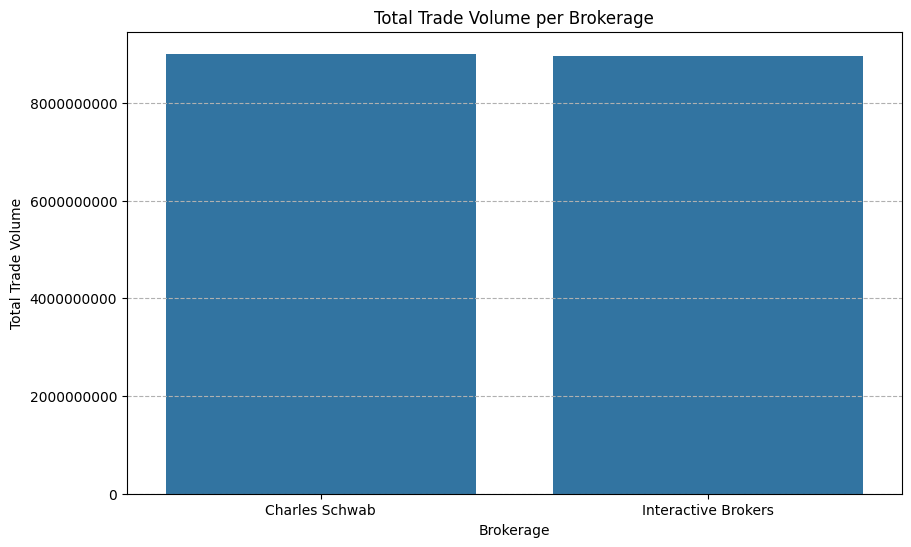

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Brokerage', y='Trade Volume', data=total_volume_per_brokerage)
plt.title('Total Trade Volume per Brokerage')
plt.xlabel('Brokerage')
plt.ylabel('Total Trade Volume')
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis
plt.grid(axis='y', linestyle='--')
plt.show()

### Top 5 Most Traded Tickers Overall

In [ ]:
top_5_traded_tickers = df.groupby('Ticker')['Quantity'].sum().nlargest(5).reset_index()

print("Top 5 Most Traded Tickers Overall (by Quantity):")
display(top_5_traded_tickers)

Top 5 Most Traded Tickers Overall (by Quantity):


,Ticker,Quantity
0,PG,737873
1,JPM,733970
2,CRM,716212
3,BAC,712088
4,V,709875


### Trend Line of Trade Volume Over Time for Top 5 Tickers

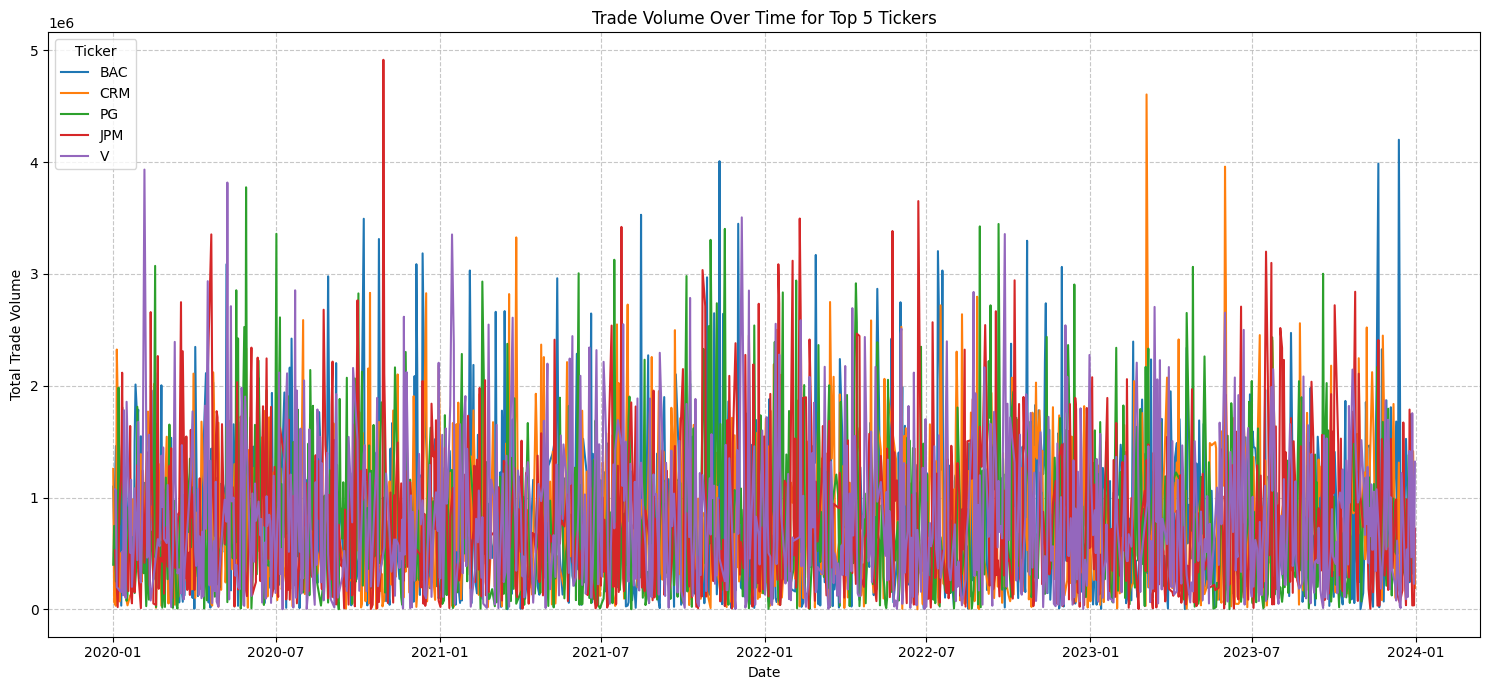

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the list of top 5 tickers
top_5_tickers_list = top_5_traded_tickers['Ticker'].tolist()

# Filter the original DataFrame for these top 5 tickers
df_top_5_tickers = df[df['Ticker'].isin(top_5_tickers_list)].copy()

# Group by Date and Ticker and sum the Trade Volume
trade_volume_over_time = df_top_5_tickers.groupby(['Date', 'Ticker'])['Trade Volume'].sum().reset_index()

# Plot the trend line
plt.figure(figsize=(15, 7))
sns.lineplot(x='Date', y='Trade Volume', hue='Ticker', data=trade_volume_over_time)
plt.title('Trade Volume Over Time for Top 5 Tickers')
plt.xlabel('Date')
plt.ylabel('Total Trade Volume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Ticker')
plt.tight_layout()
plt.show()

### Average Trade Volume per Brokerage as a Percentage of Overall Total Volume

In [ ]:
# Calculate the overall total trade volume across all brokerages
overall_total_trade_volume = df['Trade Volume'].sum()

# Use the previously calculated average_volume_per_brokerage DataFrame
# Calculate the percentage
average_volume_percentage = average_volume_per_brokerage.copy()
average_volume_percentage['Percentage of Total Volume'] = (average_volume_percentage['Trade Volume'] / overall_total_trade_volume) * 100

print("Average Trade Volume per Brokerage as a Percentage of Overall Total Volume:")
display(average_volume_percentage)

Average Trade Volume per Brokerage as a Percentage of Overall Total Volume:


,Brokerage,Trade Volume,Percentage of Total Volume
0,Charles Schwab,503356.254200,0.002803
1,Interactive Brokers,501844.158699,0.002795


### Box Plot of Trade Volumes Across Brokerages

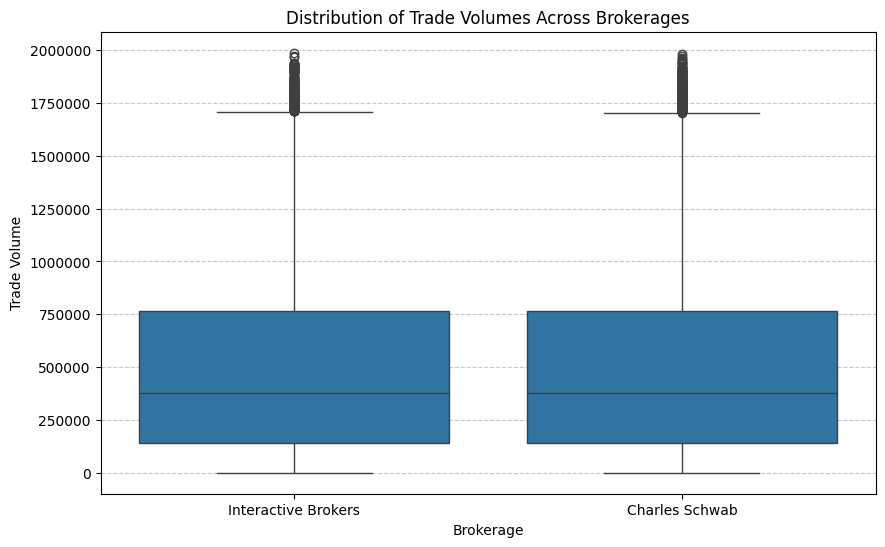

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='Brokerage', y='Trade Volume', data=df)
plt.title('Distribution of Trade Volumes Across Brokerages')
plt.xlabel('Brokerage')
plt.ylabel('Trade Volume')
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
initial_rows = len(df)
df['Brokerage'] = df['Brokerage'].str.strip()
df.dropna(subset=['Brokerage'], inplace=True)
print(f"'Brokerage' column stripped of whitespace and nulls removed. Removed {initial_rows - len(df)} rows. Remaining rows: {len(df)}")

display(df.head())
df.info()

'Brokerage' column stripped of whitespace and nulls removed. Removed 357 rows. Remaining rows: 35728


,Date,Ticker,Buy/Sell,Quantity,Price,Brokerage
0,2021-01-03,JPM,Sell,357,365.17,Interactive Brokers
1,2023-06-04,TSLA,Buy,490,1339.89,Interactive Brokers
2,2022-04-16,BRK.A,Sell,783,707.77,Interactive Brokers
3,2020-12-09,CRM,Sell,342,368.65,Charles Schwab
5,2023-05-10,SBUX,Buy,512,853.73,Charles Schwab


<class 'pandas.core.frame.DataFrame'>
Index: 35728 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       35728 non-null  datetime64[ns]
 1   Ticker     35728 non-null  object        
 2   Buy/Sell   35728 non-null  object        
 3   Quantity   35728 non-null  int64         
 4   Price      35728 non-null  float64       
 5   Brokerage  35728 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 1.9+ MB


### Correlation between Trade Volume and Price

In [ ]:
correlation = df['Trade Volume'].corr(df['Price'])
print(f"Correlation between Trade Volume and Price: {correlation:.4f}")

Correlation between Trade Volume and Price: 0.6518


### Regression Analysis: Predicting Price from Trade Volume

In [ ]:
import statsmodels.api as sm

# Define the dependent and independent variables
Y = df['Price']
X = df['Trade Volume']

# Add a constant to the independent variable for the intercept term
X = sm.add_constant(X)

# Create and fit the OLS (Ordinary Least Squares) model
model = sm.OLS(Y, X)
results = model.fit()

# Print the regression summary
print(results.summary())


                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.425
Model:                            OLS   Adj. R-squared:                  0.425
Method:                 Least Squares   F-statistic:                 2.639e+04
Date:                Mon, 24 Aug 2026   Prob (F-statistic):               0.00
Time:                        04:21:58   Log-Likelihood:            -2.6776e+05
No. Observations:               35728   AIC:                         5.355e+05
Df Residuals:                   35726   BIC:                         5.355e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          574.5550      3.496    164.344   

The regression summary above provides a detailed statistical output of the model. Key points to look for include:

*   **R-squared**: Indicates the proportion of the variance in the dependent variable (Price) that is predictable from the independent variable (Trade Volume).
*   **Coefficients**: The `const` is the intercept, and the coefficient for `Trade Volume` indicates how much the Price is expected to change for each unit increase in Trade Volume.
*   **P-values**: For each coefficient, the p-value (P>|t|) helps determine if the coefficient is statistically significant. A p-value less than 0.05 typically indicates significance.
*   **F-statistic**: Tests the overall significance of the regression model.

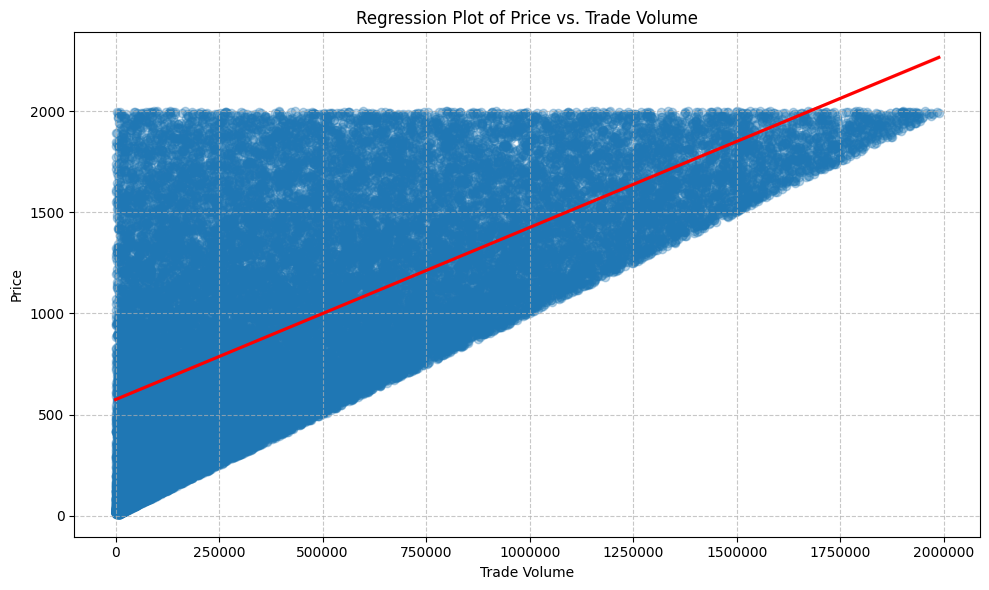

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the regression line
plt.figure(figsize=(10, 6))
sns.regplot(x='Trade Volume', y='Price', data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Regression Plot of Price vs. Trade Volume')
plt.xlabel('Trade Volume')
plt.ylabel('Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.ticklabel_format(style='plain', axis='x') # Prevent scientific notation on x-axis
plt.tight_layout()
plt.show()

In [24]:
# Install the python-pptx library
!pip install python-pptx -q

from pptx import Presentation
from pptx.util import Inches, Pt
from google.colab import files

# 1. Initialize the presentation
prs = Presentation()

# Function to safely add bullet points
def add_bullet_points(tf, points):
    for i, point in enumerate(points):
        if i == 0:
            p = tf.text_frame.paragraphs[0]
        else:
            p = tf.text_frame.add_paragraph()
        p.text = point
        p.level = 0

# --- Slide 1: Title Slide ---
title_slide_layout = prs.slide_layouts[0]
slide1 = prs.slides.add_slide(title_slide_layout)
title1 = slide1.shapes.title
subtitle1 = slide1.placeholders[1]
title1.text = "Stock Trade Data Analysis & Predictive Modeling"
subtitle1.text = "Executive Summary"

# --- Slide 2: Project Overview & Engineering ---
bullet_slide_layout = prs.slide_layouts[1]
slide2 = prs.slides.add_slide(bullet_slide_layout)
shapes2 = slide2.shapes
shapes2.title.text = "Project Overview & Engineering"
body_shape2 = shapes2.placeholders[1]
points2 = [
    "Objective: Ingest and process 50,000 raw trade records (Jan 2020 – Dec 2023) to uncover market trends and evaluate volume-price relationships.",
    "Data Pipeline: Addressed 1–3% missing values, mismatched date formats, and string-currency artifacts.",
    "Outcome: Successfully refined the dataset to 35,728 clean, valid trade records ready for exploratory analysis."
]
add_bullet_points(body_shape2, points2)

# --- Slide 3: Key Exploratory Findings ---
slide3 = prs.slides.add_slide(bullet_slide_layout)
shapes3 = slide3.shapes
shapes3.title.text = "Key Exploratory Findings"
body_shape3 = shapes3.placeholders[1]
points3 = [
    "Top Equities: Procter & Gamble (PG) led overall trade volume (737,873 shares), closely followed by JPM, CRM, BAC, and V.",
    "Brokerage Parity: Market share was highly competitive; Charles Schwab processed $9.006 billion in total volume, narrowly edging out Interactive Brokers at $8.95 billion.",
    "Average Trade Size: Transaction averages remained balanced across platforms, hovering around $501k–$503k per trade."
]
add_bullet_points(body_shape3, points3)

# --- Slide 4: Predictive Modeling Insights ---
slide4 = prs.slides.add_slide(bullet_slide_layout)
shapes4 = slide4.shapes
shapes4.title.text = "Predictive Modeling Insights"
body_shape4 = shapes4.placeholders[1]
points4 = [
    "Market Correlation: Identified a moderately strong positive correlation (0.6518) between total Trade Volume and Price.",
    "Regression Analysis: Built an Ordinary Least Squares (OLS) regression model yielding an R-squared of 0.425, indicating 42.5% of stock price variance is explained by volume in this dataset.",
    "Statistical Significance: A p-value of 0.000 confirmed that trade volume is a highly significant predictor within the model parameters."
]
add_bullet_points(body_shape4, points4)

# 2. Save the presentation
filename = 'Executive_Summary_Stock_Analysis.pptx'
prs.save(filename)
print(f"Successfully generated: {filename}")

# 3. Trigger automatic download to local machine
files.download(filename)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 11.9 MB/s eta 0:00:00
Successfully generated: Executive_Summary_Stock_Analysis.pptx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>